In [108]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# 06_rq3_regression.py
# Purpose of Script: Perform Regression Analysis for Prediction of Synthetic
# Media
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Initialization ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Google Drive
#~~~~~~~~~~~~~~~~~~~~~~~~~~
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [109]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Libraries
#~~~~~~~~~~~~~~~~~~~~~~~~~~
import numpy as np
import pandas as pd
import gc
import duckdb
import calendar
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import chi2_contingency
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.dates as mdates

In [110]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Print Versions
#~~~~~~~~~~~~~~~~~~~~~~~~~~
print(f"Numpy version = {np.__version__}")
print(f"Pandas version = {pd.__version__}")
print(f"DuckDB version = {duckdb.__version__}")

Numpy version = 2.0.2
Pandas version = 2.2.2
DuckDB version = 1.3.2


In [111]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Initiate Duck Connection
#~~~~~~~~~~~~~~~~~~~~~~~~~~
con = duckdb.connect()

#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Define Input/Output Paths
#~~~~~~~~~~~~~~~~~~~~~~~~~~
### Input
path_samp = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/01_final_data/03_samples/"
path_clean = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/01_final_data/02_clean/"
path_out = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/03_outputs/"
path_dup = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/01_final_data/05_duplicates/"

#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Seed
#~~~~~~~~~~~~~~~~~~~~~~~~~~
random_seed = 42

In [112]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Hard Coded Tables ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#### High Level Category Table - Shortened Cleaning Categories In Base Data
df_cont_cat = pd.DataFrame({
"cat_abkurzung" : ["aw","ci","cv","cvaw","dppv","ihs","ipi","necde","nsn","ovt",
                   "pm","rps","sf","sh","upp","v","sops","posc","historic_or_empty"],
"cat_full" : ["animal_welfare","consumer_information","cyber_violence",
              "cyber_violence_against_women","data_protection_and_privacy_violations",
              "illegal_or_harmful_speech","intellectual_property_infringements",
              "negative_effects_on_civic_discourse_or_elections",
              "not_specific_notice", "other_violation_tc", "protection_of_minors",
              "risk_for_public_security","scams_and_fraud","self_harm",
              "unsafe_and_prohibited_products","violence",
              "scope_of_platform_service",
              "pornography_or_sexualized_content", "historic_or_empty"]})

#### High Level Category Table - Renamed Columns in RQ3 Table
df_cont_cat_rq3 = pd.DataFrame({
  "category" : ["aw_cat_high_level","ci_cat_high_level", "cv_cat_high_level",
  "cvaw_cat_high_level","dppv_cat_high_level","ihs_cat_high_level","ipi_cat_high_level",
  "necde_cat_high_level","nsn_cat_high_level","ovt_cat_high_level","pm_cat_high_level",
  "rps_cat_high_level","sf_cat_high_level","sh_cat_high_level","upp_cat_high_level",
  "v_cat_high_level","NA_cat_high_level","historic_cat_high_level","posc_cat_high_level",
  "sops_cat_high_level",],
  "cat_renamed" : ["animal_welfare", "consumer_information", "cyber_violence",
  "cyber_violence_against_women", "data_proection_and_privacy","illegal_or_harmful_speech",
  "intellectual_prop_infringement", "negative_effects_on_civic_dicourse_or_elections",
  "category_not_specified", "other_violation_terms_conditions",
  "protection_of_minors", "public_security_risk", "scams_and_fraud", "self_harm",
  "unsafe_and_prohibited_products", "violence", "category_NA",
  "historic", "pornographic_or_sexual_content","scope_of_platform_service"]})

In [113]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import RQ3 Sample
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
df_rq3 = con.execute(f""" select * from '{path_samp}rq3_quant_final.parquet'""").df()

In [114]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Format RQ3 Sample
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Focus Only On Strict High Level Content Categories
### Look at Renamed Table
#### Assign Base Columns
base_cols = ["platform","date","syn_flag","illegal_flag","total_sor_entries"]

#### Find Which Category Columns are in RQ3 Table
matched_cols = [col for col in df_cont_cat_rq3["cat_renamed"] if col in df_rq3.columns]

#### Subset RQ3
df_rq3 = df_rq3[base_cols + matched_cols]

In [115]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Aggregate RQ3 Sample
#~~~~~~~~~~~~~~~~~~~~~~~~~~
### Sum everything by platform and synth flag
group_cols = ["platform","syn_flag"]

df_rq3_agg = (df_rq3.drop(columns="illegal_flag").groupby(group_cols, as_index=False).sum(numeric_only=True))

In [116]:
### Check Category Sums
#### Define Cols
exclude = ["platform","date", "syn_flag", "total_sor_entries"]
category_cols = [c for c in df_rq3_agg.columns if c not in exclude]

#### Sum
df_rq3_agg["cat_sum"] = df_rq3_agg[category_cols].sum(axis=1)

### Check Match
df_rq3_agg["check_match"] = (df_rq3_agg["cat_sum"] == df_rq3_agg["total_sor_entries"])#

### Find Mismatch
df_rq3_agg["diff"] = (df_rq3_agg["total_sor_entries"] - df_rq3_agg["cat_sum"])

### Check Total SORS
total_sor_check = (df_rq3[["platform","total_sor_entries"]].groupby("platform").sum())

### No Problems - Drop Columns
df_rq3_agg = df_rq3_agg.drop(columns=["cat_sum","check_match","diff"])

In [117]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Duplicates
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
df_dup_face = con.execute(f""" select * from '{path_dup}09_rq3/facebook_rq3_quant.parquet'""").df()
df_dup_inst = con.execute(f""" select * from '{path_dup}09_rq3/instagram_rq3_quant.parquet'""").df()
df_dup_tiktok = con.execute(f""" select * from '{path_dup}09_rq3/tiktok_rq3_quant.parquet'""").df()

# Concatenate Facebook and Instagram
df_dup = pd.concat([df_dup_face, df_dup_inst])

# Fill NAs
df_dup = df_dup.fillna(0)

# Drop Illegal Flag
df_dup = df_dup.drop(columns=["date","illegal_flag","historic_or_empty_cat_detailed"])
df_dup_tiktok = df_dup_tiktok.drop(columns=["date","illegal_flag","historic_or_empty_cat_detailed"])

In [118]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Final RQ3 Table - Remove Duplicates
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Merge Duplicates
df_rq3_final = df_rq3_agg.merge(df_dup, on = ["platform","syn_flag"],
                                suffixes=("","_dup"),
                                how="left")

# Fill NAs
df_rq3_final = df_rq3_final.fillna(0)

# Minus Duplicates
dup_cols = ["total_sor_entries","data_proection_and_privacy",
            "illegal_or_harmful_speech","other_violation_terms_conditions",
            "scams_and_fraud"]

for col in dup_cols:
  df_rq3_final[col] = df_rq3_final[col] - df_rq3_final[f"{col}_dup"]

# Drop Columns
for col in dup_cols:
  df_rq3_final = df_rq3_final.drop(columns=[f"{col}_dup"])

# Rename Column
df_rq3_final = df_rq3_final.rename(columns={"historic_or_empty_cat_high_level" : "historic"})

### Save Copy for Later
df_rq3_final_all_plat = df_rq3_final.copy()

# Filter For Only Facebook and Instagram
df_rq3_final = df_rq3_final[(df_rq3_final["platform"] == "facebook") |(df_rq3_final["platform"] == "instagram")]

In [119]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Final RQ3 Table Predictions - Remove Duplicates for TikTok
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Merge Duplicates
df_rq3_final_all_plat = df_rq3_agg.merge(df_dup_tiktok, on = ["platform","syn_flag"],
                                suffixes=("","_dup"),
                                how="left")

# Fill NAs
df_rq3_final_all_plat = df_rq3_final_all_plat.fillna(0)

# Minus Duplicates
dup_cols = ["total_sor_entries","other_violation_terms_conditions",
            "self_harm"]

for col in dup_cols:
  df_rq3_final_all_plat[col] = df_rq3_final_all_plat[col] - df_rq3_final_all_plat[f"{col}_dup"]

# Drop Columns
for col in dup_cols:
  df_rq3_final_all_plat = df_rq3_final_all_plat.drop(columns=[f"{col}_dup"])

# Rename Column
df_rq3_final_all_plat = df_rq3_final_all_plat.rename(columns={"historic_or_empty_cat_high_level" : "historic"})

In [120]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Overall Descriptive Probabilies
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Probabilites of Categories - Long Format
cat_cols = [c for c in df_rq3_final.columns if c not in ["platform","syn_flag","total_sor_entries"]]

df_rq3_final_long = df_rq3_final.melt(id_vars=["platform","syn_flag","total_sor_entries"],
                                      value_vars=cat_cols,
                                      var_name="content_category",
                                      value_name="count")

### Pivot Table
df_rq3_probs = (df_rq3_final_long.pivot_table(index="content_category",
                                              columns="syn_flag",
                                              values="count",
                                              aggfunc="sum",
                                              fill_value=0).rename(columns={0: "non_syn", 1: "syn"}))

### Calculate Probabilites
df_rq3_probs["sor_sum"] = (df_rq3_probs["syn"] + df_rq3_probs["non_syn"])
df_rq3_probs["prob"] = (df_rq3_probs["syn"] / df_rq3_probs["sor_sum"])

### Sort Table
df_rq3_probs = df_rq3_probs.sort_values("prob", ascending=False)

### Fill NA
df_rq3_probs = df_rq3_probs.fillna(0)

### Export
df_rq3_probs.to_csv(f"{path_out}06_rq3_1_content_probabilities.csv")

In [121]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Chi-Square & Cramers V
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Filter Out Non-Populated Categories
df_rq3_probs_cont = df_rq3_probs[df_rq3_probs["non_syn"] != 0]

df_contingency = (df_rq3_probs_cont[["non_syn","syn"]])

chi2, p, dof, expected = chi2_contingency(df_contingency)

### Print Results
print(f"Chi-Square = {chi2:.2f}")
print(f"df = {dof}")
print(f"p = {p:.5f}")

### Check Expected
df_expect = pd.DataFrame(expected, index=df_contingency.index,
                         columns=df_contingency.columns)

df_expect["non_syn"] = df_expect["non_syn"].round(2)
df_expect["syn"] = df_expect["syn"].round(2)

#### Cramers V
n = df_contingency.to_numpy().sum()

phi2 = chi2/n

r, k = df_contingency.shape
cramers_v = np.sqrt(phi2 / min(r-1, k-1))
print(f"cramers v = ",cramers_v)

### Generate Output
df_chi = pd.DataFrame({"Statistic":["Chi-square","Degrees of Freedom", "p-value",
                                    "Cramer's V", "Sample Size"],
                       "Value" : [f"{chi2:.2f}", dof, "<0.001" if p < 0.001 else round(p, 3),
                                  round(cramers_v, 3),
                                  f"{df_contingency.values.sum():,}"]})

# Export
df_chi.to_csv(f"{path_out}06_rq3_2_chi2_cramer.csv")

Chi-Square = 110980921.61
df = 14
p = 0.00000
cramers v =  0.3722945450477173


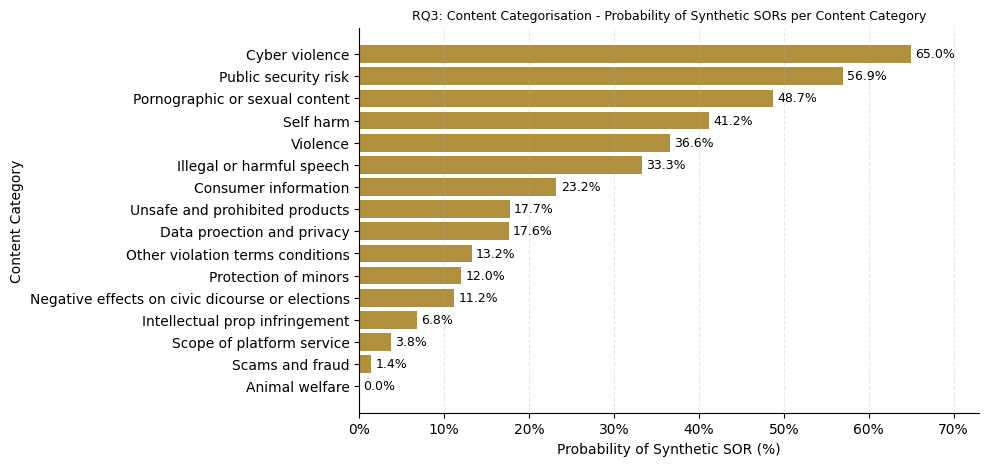

In [122]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure: Bar Chart of Categories
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Use Probability Table
df_plot = (df_rq3_probs
           .reset_index()
           .assign(**{"syn_perc": lambda x: x["prob"]*100})
           .sort_values("syn_perc", ascending=True))

df_plot["content_category"] = df_plot["content_category"].str.replace("_"," ", regex=False)
df_plot["content_category"] = df_plot["content_category"].str.capitalize()

# Plot
fig, ax = plt.subplots(figsize=(8,5))

# Colour
bar_colour = "#B0903D"

bars = ax.barh(df_plot["content_category"],
               df_plot["syn_perc"],
               color=bar_colour)

# Bar Percentages
for bar in bars:
  width = bar.get_width()
  ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
          f"{width:.1f}%", va="center", fontsize=9)

ax.set_xlabel("Probability of Synthetic SOR (%)")
ax.set_ylabel("Content Category")
ax.set_title("RQ3: Content Categorisation - Probability of Synthetic SORs per Content Category",
          fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_xlim(0, df_plot["syn_perc"].max() + 8)

# Export
plt.savefig(f"{path_out}06_rq3_4_content_cat_prob_barchart.pdf", bbox_inches="tight")


In [123]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Appendix: Observed vs Expected per Category
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## Expected vs Observed
df_app = pd.DataFrame({"observed_non_syn": df_contingency["non_syn"],
                       "expected_non_syn": df_expect["non_syn"].round(0).astype(int),
                       "observed_syn": df_contingency["syn"],
                       "expected_syn": df_expect["syn"].round(0).astype(int)})

## Sums & Perc
df_app["total"] = (df_app["observed_non_syn"] + df_app["observed_syn"])
df_app["synth_perc"] = (df_app["observed_syn"]/df_app["total"]*100).round(2)

## Difference
df_app["diff"] = (df_app["observed_syn"] - df_app["expected_syn"])

## O/E Ratio
df_app["o_e_ratio"] = (df_app["observed_syn"]/df_app["expected_syn"]).round(2)

## Export
df_app.to_csv(f"{path_out}06_rq3_3_obs_vs_expected_appendix.csv")

In [124]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Regression Sample
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
df_reg = con.execute(f""" select * from '{path_out}05_rq3_5_regression_sample.parquet' """).df()

In [125]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Train/Test Split
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Split Sample into Train and Test
### Stratify Based on Synth Target
df_train, df_test = train_test_split(df_reg, test_size=0.2,
                                     random_state = random_seed,
                                     stratify=df_reg["synth_flag"])

In [126]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Format Columns
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
df_train["p_name"] = df_train["p_name"].astype("category")
df_train["cat"] = df_train["cat"].astype("category")
df_train["cat_spec"] = df_train["cat_spec"].astype("category")
df_train["synth_flag"] = df_train["synth_flag"].astype(int)
df_train["illegal_flag"] = df_train["illegal_flag"].astype(int)
df_train["doy"] = df_train["doy"].astype(int)
df_train["day_since_start"] = df_train["day_since_start"].astype(int)
df_train["month"] = df_train["month"].astype("category")
df_train["source"] = df_train["source"].astype("category")

In [127]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Sample Description - Train/Test
#~~~~~~~~~~~~~~~~~~~~~~~~~~
def sample_summary(df, sample_name):

    # Get Overall Sample Size
    row = {"Sample": sample_name,
           "Total observations": len(df),
           "Unique Cat:": df["cat"].nunique()}

    # Get Distribution of Synth Flag
    for platform in ["f","i"]:
        row[f"{platform.lower()}_syn"] = (
            ((df["p_name"] == platform) & (df["synth_flag"] == 1)).sum())
        row[f"{platform.lower()}_non_syn"] = (
            ((df["p_name"] == platform) & (df["synth_flag"] == 0)).sum())


    return row

df_sample_des = pd.DataFrame([sample_summary(df_train, "Training"),
                        sample_summary(df_test, "Testing")])

### Export
df_sample_des.to_csv(f"{path_out}06_rq3_5_train_test_sample_des.csv")

In [128]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Model Fitting - Model 1
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Fit Regression Model: Category & Synth Flag
model = smf.logit(formula=""" synth_flag ~
                              C(cat, Treatment(reference="sf")) """,
                        data=df_train).fit(maxiter=10)

Optimization terminated successfully.
         Current function value: 0.182140
         Iterations 8


In [129]:
# Print Model Results
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:             synth_flag   No. Observations:              1119709
Model:                          Logit   Df Residuals:                  1119694
Method:                           MLE   Df Model:                           14
Date:                Tue, 04 Aug 2026   Pseudo R-squ.:                  0.2219
Time:                        08:04:49   Log-Likelihood:            -2.0394e+05
converged:                       True   LL-Null:                   -2.6211e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -4.3602      0.013   -343.672      0.000      -4.385      -4.335
C(cat, Treatment(reference="sf"))[T

In [130]:
### Export - Coefficient Table
df_summary = model.summary2().tables[1]
df_summary.to_csv(f"{path_out}06_rq3_6_logistic_regression_model.csv", index=True)

### Export - Fit Statistics
fit_stats = pd.DataFrame({"Statistic": ["Observations", "Log-Likelihood", "Likelihood Ratio chi2",
                          "LR p-value","McFadden Pseudo R²","AIC","BIC"],
                         "Value": [model.nobs, model.llf, model.llr, model.llr_pvalue,
                                   model.prsquared, model.aic, model.bic]})

fit_stats.to_csv(f"{path_out}06_rq3_7_logistic_regression_fit_stats.csv")

In [131]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Plotting Odds Ratios - Formatting ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~
odds_ratios = np.exp(model.params)
conf_int = np.exp(model.conf_int())

res = pd.DataFrame({"Variable": model.params.index,
                    "Odds Ratio" : odds_ratios,
                    "CI Lower": conf_int[0],
                    "CI Upper": conf_int[1],
                    "P-Value" : model.pvalues}).reset_index(drop=True)

# Remove Index
res = res[res["Variable"] != "Intercept"]

# Clean Variable Names
res["Variable"] = (res["Variable"]
                   .str.replace(r"C\((.*?)\)\[T\.", "", regex=True)
                   .str.replace("]", "", regex=False))

# Convert to Panda
res = pd.DataFrame(res)

# Join Category Names
res = res.merge(df_cont_cat, left_on="Variable",
                right_on="cat_abkurzung",
                how="left")

# Fill Empty
res["cat_full"] = res["cat_full"].str.replace("_"," ", regex=False)
res["cat_full"] = res["cat_full"].str.capitalize()
res["cat_full"] = "Category: " + res["cat_full"]
res["cat_full"] = res["cat_full"].fillna(res["Variable"])
res["Variable"] = res.pop("cat_full")

# Drop Shortened
res = res.drop(columns="cat_abkurzung")

# Add Reference Rows
refs = pd.DataFrame({"Variable": ["Category: Scams and fraud (Reference)"],
                     "Odds Ratio" : [1],
                     "CI Lower" : [1],
                     "CI Upper" : [1],
                     "P-Value" : [np.nan]})

res = pd.concat([refs, res], ignore_index=True)

# Organise Results Table
res_cat = (res[res["Variable"].str.startswith("Category: ")].sort_values("Odds Ratio"))

#res = pd.concat([res_plat, res_month, res_cat], ignore_index=True)
res = res_cat

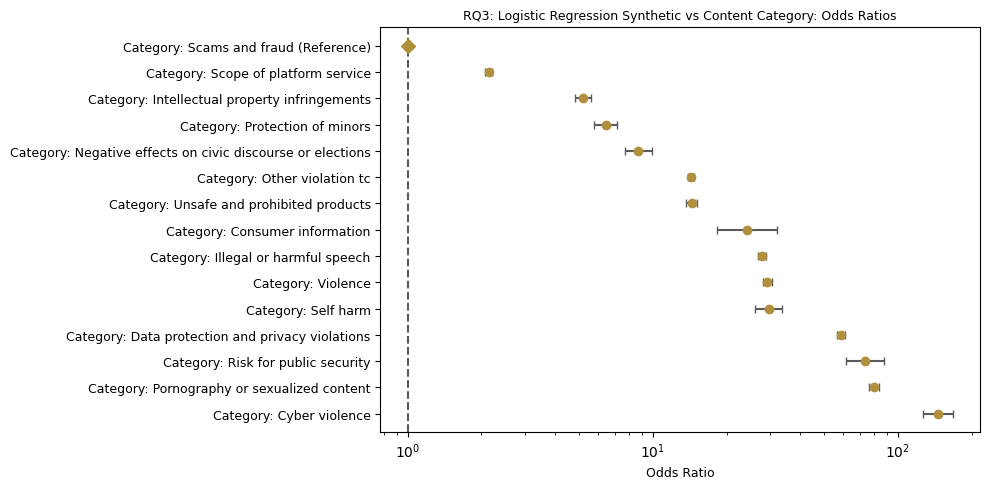

In [132]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Plot Odds Ratios ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~
fig, ax = plt.subplots(figsize=(10, 5))

# Plot Odds Ratios
ax.errorbar(res["Odds Ratio"], res["Variable"],
    xerr=[res["Odds Ratio"] - res["CI Lower"],
          res["CI Upper"] - res["Odds Ratio"]],
    fmt="o", capsize=3, color="#B0903D",
    ecolor="#5A5A5A" )

# Reference Line
ax.axvline(1, linestyle="--", color="#5A5A5A")

# Reference Variables
refs = res["Variable"].str.contains("Reference")
ax.scatter(res.loc[refs, "Odds Ratio"], res.loc[refs, "Variable"],
           marker="D", s=50, zorder=3, color="#B0903D")

# Format Graph
ax.set_xlabel("Odds Ratio", fontsize=9)
ax.tick_params(axis="y", labelsize=9)
ax.set_title("RQ3: Logistic Regression Synthetic vs Content Category: Odds Ratios", fontsize=9)
ax.set_xscale("log")
ax.invert_yaxis()
plt.tight_layout()

# Export
plt.savefig(f"{path_out}06_rq3_8_odds_ratio_model_1.pdf", bbox_inches="tight")

plt.show()

In [133]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Additional Prediction Analysis ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Apply Model Parameters to Test Set - Obtain Probabilites
df_test["pred_prob"] = model.predict(df_test)

# Convert Probabilites to Predicted Flag
df_test["synth_flag_pred"] = (df_test["pred_prob"] >= 0.5).astype(int)

In [134]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Performance Metrics - Model 1 ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Confusion Matrix
cm = confusion_matrix(df_test["synth_flag"],
                      df_test["synth_flag_pred"])

df_cm = pd.DataFrame(cm, index=["actual_non_syn", "actual_syn"],
                         columns=["predicted_non_syn", "predicted_syn"])

# Accurarcy Ratio
accuracy = accuracy_score(df_test["synth_flag"],
               df_test["synth_flag_pred"])

df_accuracy = pd.DataFrame({"Metric": ["Accuracy"],
                            "Value": [accuracy]})

# Precision/Recall/F1 Score
df_report = classification_report(df_test["synth_flag"],
                               df_test["synth_flag_pred"],
                                  output_dict=True)

df_report = (pd.DataFrame(df_report).transpose().round(3))

### Export
df_cm.to_csv(f"{path_out}06_rq3_xx_app_confusion_matrix.csv")
df_accuracy.to_csv(f"{path_out}06_rq3_xx_app_accuracy_ratio.csv")
df_report.to_csv(f"{path_out}06_rq3_xx_app_report_metrics.csv")

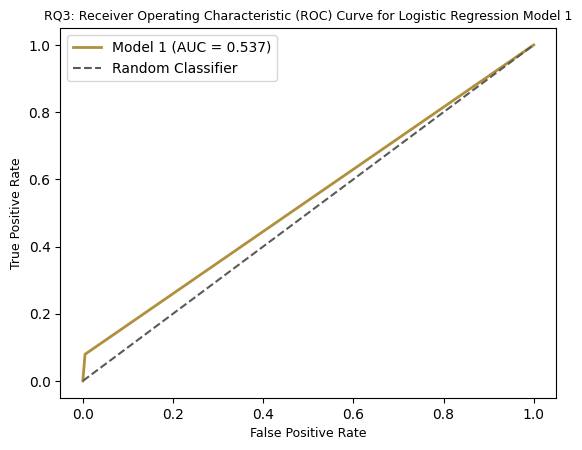

In [135]:
# ROC Curve
fpr, tpr, _ = roc_curve(
    df_test["synth_flag"],
    df_test["synth_flag_pred"])

auc = roc_auc_score(
    df_test["synth_flag"],
    df_test["synth_flag_pred"])

plt.plot(fpr, tpr, label=f"Model 1 (AUC = {auc:.3f})",
         linewidth=2, color="#B0903D")
plt.plot([0,1],[0,1],"--", label="Random Classifier",
         color="#5A5A5A")
plt.legend()
plt.xlabel("False Positive Rate", fontsize=9)
plt.ylabel("True Positive Rate", fontsize=9)
plt.title("RQ3: Receiver Operating Characteristic (ROC) Curve for Logistic Regression Model 1", fontsize=9)

# Export
plt.savefig(f"{path_out}06_rq3_9_roc_curve_m1.pdf", bbox_inches="tight")

In [136]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Predictions on Other Platforms - Apply Model ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Filter Table for Required Platforms
df_rq3_pred = df_rq3_final_all_plat[(df_rq3_final_all_plat["platform"] == "tiktok") |
                                    (df_rq3_final_all_plat["platform"] == "snapchat") |
                                    (df_rq3_final_all_plat["platform"] == "whatsapp") |
                                    (df_rq3_final_all_plat["platform"] == "youtube")]

### Filter for Non-Syn Flag
df_rq3_pred = df_rq3_pred[df_rq3_pred["syn_flag"] == 0]

### Drop Columns
df_rq3_pred = df_rq3_pred.drop(columns=["syn_flag","total_sor_entries"])

### Map Shortening
df_cont_cat_rq3["category"] = (df_cont_cat_rq3["category"].str.replace("_cat_high_level$", "", regex=True))

### Create Dictionary
rename_dict = dict(zip(df_cont_cat_rq3["cat_renamed"],df_cont_cat_rq3["category"]))

### Rename DataFrame
df_rq3_pred = df_rq3_pred.rename(columns=rename_dict)

### Wide to Long
df_rq3_pred = df_rq3_pred.melt(id_vars="platform", var_name="cat", value_name="count")

### Sort
df_rq3_pred = df_rq3_pred.sort_values(["platform","cat"])

### Remove Non-Populated Animal Welfare
df_rq3_pred = df_rq3_pred[df_rq3_pred["cat"] != "aw"]

### Rename Historic
df_rq3_pred["cat"] = df_rq3_pred["cat"].replace({"historic": "historic_or_empty"})

In [137]:
### Apply Model
df_rq3_pred["pred_prob"] = model.predict(df_rq3_pred)

In [138]:
### Estimate Synthetic
df_rq3_pred["syn_est"] = (df_rq3_pred["count"] * df_rq3_pred["pred_prob"])

In [139]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Prediction Results - Aggregation ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Aggregate - Total Basis
df_pred_all = (df_rq3_pred
               .groupby("platform", as_index=False)
               .agg(total_sors = ("count", "sum"),
                    est_syn = ("syn_est", "sum")))

### Esimate Prevalence
df_pred_all["est_prev"] = (df_pred_all["est_syn"]/df_pred_all["total_sors"]*100)

In [140]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Estimation Plotting ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Apply Model to Daily Data and Plot Per Month - Take RQ1 Data As Base
df_rq3_plot = con.execute(f""" select * from '{path_samp}rq1_final.parquet'""").df()

# Filter Sample Only for Observation Period (Sample Collection Added Dates with 0 Entries)
df_rq3_plot = df_rq3_plot[df_rq3_plot["date"] <= "2026-05-31 00:00:00"]

In [141]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Format RQ3 Plotting Sample
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#### Assign Base Columns
base_cols = ["platform","date","total_sor_entries"]

#### Find Which Category Columns are in RQ3 Table
matched_cols = [col for col in df_cont_cat_rq3["cat_renamed"] if col in df_rq3.columns]

#### Historic or Potentially Empty Columns
#hist_cols = ["historic_or_empty_cat_high_level"]

#### Subset RQ3
df_rq3_plot = df_rq3_plot[base_cols + matched_cols]

In [142]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
#### Deal with Duplicates
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_dup_face = con.execute(f""" select * from '{path_dup}07_rq1/facebook_rq1.parquet'""").df()
df_dup_inst = con.execute(f""" select * from '{path_dup}07_rq1/instagram_rq1.parquet'""").df()
df_dup_tiktok = con.execute(f""" select * from '{path_dup}07_rq1/tiktok_rq1.parquet'""").df()

# Concatenate Duplicates
df_dup = pd.concat([df_dup_face, df_dup_inst, df_dup_tiktok])

# Fill NAs
df_dup = df_dup.fillna(0)

# Filter Duplicates by Columns
#### Assign Base Columns
base_cols = ["platform","date", "total_sor_entries"]

#### Find Which Category Columns are in Dup Table
matched_cols = [col for col in df_cont_cat_rq3["cat_renamed"] if col in df_dup.columns]

df_dup = df_dup[base_cols + matched_cols]

# Merge Duplicates
df_rq3_plot["date"] = pd.to_datetime(df_rq3_plot["date"])
df_dup["date"] = pd.to_datetime(df_dup["date"])
df_rq3_plot = df_rq3_plot.merge(df_dup, on = ["platform","date"],
                                suffixes=("","_dup"),
                                how="left")

# Fill NAs
df_rq3_plot = df_rq3_plot.fillna(0)

# Minus Duplicates
dup_cols = ["total_sor_entries","other_violation_terms_conditions",
            "data_proection_and_privacy","illegal_or_harmful_speech",
            "scams_and_fraud","self_harm"]

for col in dup_cols:
  df_rq3_plot[col] = df_rq3_plot[col] - df_rq3_plot[f"{col}_dup"]

# Drop Columns
for col in dup_cols:
  df_rq3_plot = df_rq3_plot.drop(columns=[f"{col}_dup"])


In [143]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Format Data
#~~~~~~~~~~~~~~~~~~~~~~~~~~
### Rename DataFrame
df_rq3_plot = df_rq3_plot.rename(columns=rename_dict)

### Wide to Long
df_rq3_plot = df_rq3_plot.melt(id_vars=["platform","date","total_sor_entries"],
                               var_name="cat", value_name="count")

### Sort
df_rq3_plot = df_rq3_plot.sort_values(["platform","date","cat"])

### Remove Non-Populated Animal Welfare
df_rq3_plot = df_rq3_plot[df_rq3_plot["cat"] != "aw"]

In [144]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Apply Model
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_rq3_plot["pred_prob"] = model.predict(df_rq3_plot)

### Find Number of Synthetic SORs
df_rq3_plot["est_syn"] = (df_rq3_plot["count"] * df_rq3_plot["pred_prob"])

### Esimate Prevalence
df_rq3_plot["est_prev"] = (df_rq3_plot["est_syn"]/df_rq3_plot["total_sor_entries"]*100)

In [145]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Aggregate to Daily
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_rq3_plot = (df_rq3_plot
               .groupby(["platform","date"], as_index=False)
               .agg(total_sors=("total_sor_entries", "first"),
                    est_syn=("est_syn", "sum")))

### Esimate Prevalence
df_rq3_plot["est_prev"] = (df_rq3_plot["est_syn"]/df_rq3_plot["total_sors"]*100)

### Roll Prevalence
df_rq3_plot["roll_syn_est"] = (df_rq3_plot.groupby("platform")["est_prev"]
                               .rolling(30, min_periods=1)
                               .mean()
                               .reset_index(drop=True)).round(3)

### Format
df_rq3_plot["platform"] = df_rq3_plot["platform"].str.capitalize()


In [146]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Data from RQ1
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
df_rq1_data = pd.read_csv(f"{path_out}03_rq1_xx_rq1_plot_base_sample.csv")

### Merge Observed Rolls to Estimated
df_rq1_data = df_rq1_data[["platform","date","roll_syn_prev"]]
df_rq1_data = df_rq1_data.rename(columns={"roll_syn_prev": "roll_syn"})

### Format
df_rq1_data["date"] = pd.to_datetime(df_rq1_data["date"])

df_plot = df_rq3_plot.merge(df_rq1_data,on=["platform","date"], how="left")

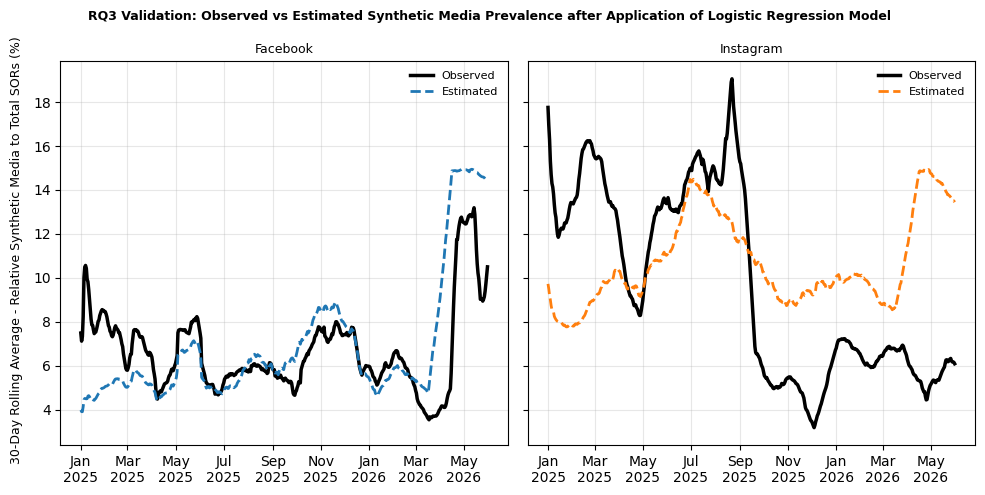

In [147]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Plotting - Validation
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Rolling Prevalance Graph - One Panel Per Platform - RQ1 Code
#### Synthetic relative to total over time - One Panel Per Platform

# Define Platforms
platform_order = ["Facebook","Instagram"]

# Define Colours
colours = {"Facebook": "tab:blue", "Instagram": "tab:orange"}

fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex=True, sharey=True)

axes = axes.flatten()

for i, (ax, platform) in enumerate(zip(axes, platform_order)):

  d = df_plot[df_plot["platform"] == platform].sort_values("date")

  # Observed Synthetic
  ax.plot(d["date"], d["roll_syn"], color="black", linewidth=2.5,
          label="Observed")

  # Estimated Synthetic
  ax.plot(d["date"], d["roll_syn_est"], color=colours[platform], linewidth=2,
          linestyle="--", label="Estimated")

  ax.set_title(platform.capitalize(), fontsize=9)
  ax.grid(alpha=0.3)

  ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
  ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
  ax.legend(frameon=False, fontsize=8)

fig.supylabel("30-Day Rolling Average - Relative Synthetic Media to Total SORs (%)",
              fontsize=9)

fig.suptitle("RQ3 Validation: Observed vs Estimated Synthetic Media Prevalence after Application of Logistic Regression Model",
    fontsize=9,fontweight="bold")

plt.tight_layout()

plt.savefig(f"{path_out}06_rq3_10_observed_estimated_syn_regression.pdf",
            format="pdf", dpi=300, bbox_inches="tight")


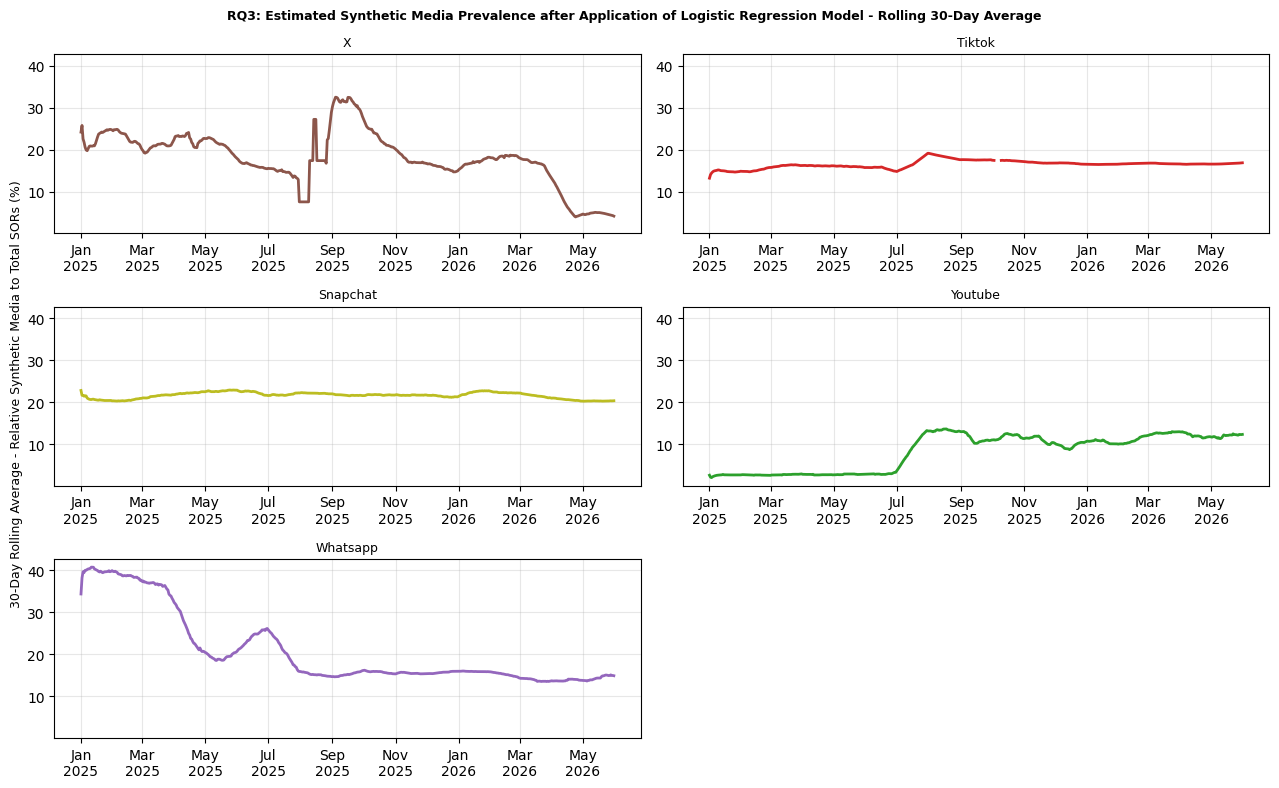

In [148]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Plotting - Estimation
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Define Platforms
platform_order = ["X","Tiktok","Snapchat","Youtube","Whatsapp"]

# Define Colours
colours = {"X": "tab:brown","Tiktok": "tab:red",
           "Youtube" : "tab:green", "Whatsapp": "tab:purple",
           "Snapchat": "tab:olive"}

fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharex=False, sharey=True)

axes = axes.flatten()

for ax, platform in zip(axes, platform_order):

    d = df_rq3_plot[df_rq3_plot["platform"] == platform].sort_values("date")

    ax.plot(d["date"], d["roll_syn_est"], color=colours[platform], linewidth=2)
    ax.set_title(platform, fontsize=9)
    ax.grid(alpha=0.3)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

for ax in axes:
  ax.tick_params(axis="y", labelleft=True)

# Remove the unused subplot
fig.delaxes(axes[-1])

fig.supylabel("30-Day Rolling Average - Relative Synthetic Media to Total SORs (%)",
              fontsize=9)

fig.suptitle("RQ3: Estimated Synthetic Media Prevalence after Application of Logistic Regression Model - Rolling 30-Day Average",
             fontsize=9, fontweight="bold")

plt.tight_layout()

plt.savefig(f"{path_out}06_rq3_11_estimated_prevelance_other_plats_regression.pdf",
            format="pdf", dpi=300, bbox_inches="tight")


In [149]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Validation Table
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
df_rq1_data = pd.read_csv(f"{path_out}03_rq1_xx_rq1_plot_base_sample.csv")

## Aggregate to Find Total Synthetic SORs
df_rq1_data = df_rq1_data[["platform","total_sor_entries","syn_all"]]
df_rq1_data = (df_rq1_data.groupby("platform", as_index=False).sum(numeric_only=True))

# Calculate Syn Prev
df_rq1_data["real_syn_prev"] = (df_rq1_data["syn_all"] / df_rq1_data["total_sor_entries"]*100)

### Cut-Down and Aggregate Estimated SORs
df_plot_cut = df_plot[["platform","est_syn"]]
df_plot_cut = (df_plot_cut.groupby("platform", as_index=False).sum(numeric_only=True))

### Merge
df_rq1_data = df_rq1_data.merge(df_plot_cut, on=["platform"], how="left")

### Estimate Calculate Estimate Prevalence
df_rq1_data["est_prev"] = (df_rq1_data["est_syn"]/df_rq1_data["total_sor_entries"]*100)

### Calculate Difference
df_rq1_data["diff_prev"] = (df_rq1_data["real_syn_prev"] - df_rq1_data["est_prev"])

### Export
df_rq1_data.to_csv(f"{path_out}06_rq3_12_real_vs_predicted_synthetic_media_prev.csv")